# MHCflurry + ESMCBA: scoring every design, one shared embedding space

Every design from **19 of the 20 panel structures** (full pMHC+TCR context, 4 models, unique peptides
only) scored with two independent external predictors it has never seen before: **MHCflurry**
(allele-specific neural network ensemble, trained on IEDB binding-affinity data) and **ESMCBA**
(ESM-Cambrian protein language model, fine-tuned per-HLA on binding affinity, this project's own tool).
4MJI is excluded here: its peptide is presented by **HLA-B\*51:01**, not HLA-A\*02:01 like every other
structure in the panel, and both predictors below are single-allele (A\*02:01) models -- scoring a
B\*51:01-restricted peptide against them would be a category error, not just added noise. ESMCBA's
960-dim embeddings for the remaining peptides are reduced to one shared 2D UMAP -- fit jointly over the
whole set, not per model or per structure -- so every subsequent plot below is the *same* layout, just
recolored.

1. Design distribution: across models, across resolution, across recovery
2. The scored table
3. UMAP, 2x3 panel: model / MHCFlurry IC50 / ESMCBA score / hamming to native / MPNN score / anchors
4. Does ESMCBA agree with MHCflurry at all? (sanity check on the two external predictors)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, gaussian_kde, chi2_contingency, fisher_exact, mannwhitneyu

ROOT = Path("/home/ubuntu/if-mhc")
FIG_DIR = ROOT / "figures/fig_panel6_mhcflurry_esmcba_umap"
FIG_DIR.mkdir(exist_ok=True, parents=True)
MODELS = ["vanilla", "noMHC", "ESM-IF1", "LigandMPNN"]
MODEL_COLOR = {"vanilla": "#0072B2", "noMHC": "#E69F00", "ESM-IF1": "#009E73", "LigandMPNN": "#CC79A7"}
MODEL_LABEL = {"vanilla": "ProteinMPNN", "noMHC": "ProteinMPNN (no MHC)", "ESM-IF1": "ESM-IF1",
               "LigandMPNN": "LigandMPNN"}
GRAY = "#B0B0B0"

meta = pd.read_csv(ROOT / "outputs/analysis/panel_unique_peptides_metadata.csv")
mhcflurry = pd.read_csv(ROOT / "outputs/analysis/panel_unique_peptides_mhcflurry.csv")
esmcba = pd.read_csv(ROOT / "outputs/analysis/panel_unique_peptides_esmcba.csv")
df = meta.merge(mhcflurry, on="peptide", how="left").merge(esmcba, on="peptide", how="left")
print(f"{len(df)} (pdb, model, peptide) rows, {df['peptide'].nunique()} distinct peptides, "
     f"{df['pdb'].nunique()} structures")
df.head()

3776 (pdb, model, peptide) rows, 3557 distinct peptides, 19 structures


,pdb,model,peptide,score,native,resolution_A,hamming_to_native,p2_recovered,pomega_recovered,n_anchors_recovered,mhcflurry_ic50_nM,mhcflurry_percentile,esmcba_prediction,UMAP_1,UMAP_2
0,2P5W,vanilla,MLPQYDTPF,0.9547,SLLMWITQC,2.2,7,True,False,1,1429.902708,2.006875,4.331568,14.752317,11.570993
1,2P5W,vanilla,MLPNYFTPF,0.9283,SLLMWITQC,2.2,7,True,False,1,390.770529,1.212000,4.197661,13.598901,8.389266
2,2P5W,vanilla,MLPNYFTRF,0.9868,SLLMWITQC,2.2,7,True,False,1,962.015451,1.722375,4.144500,13.304355,7.131737
3,2P5W,vanilla,MLPNYDTPF,0.9947,SLLMWITQC,2.2,7,True,False,1,1342.397035,1.955375,4.222630,13.701857,8.735578
4,2P5W,vanilla,MLPNWFTPF,0.9704,SLLMWITQC,2.2,6,True,False,1,263.995545,1.017000,4.247863,14.132448,9.722418


## 1. Design distribution: across models, across resolution, across recovery

Unique-design counts per model, unique counts vs. each structure's resolution, and the hamming-distance
(to that structure's own native peptide) distribution per model -- all at the same (pdb, model, unique
peptide) granularity used for the scoring below.

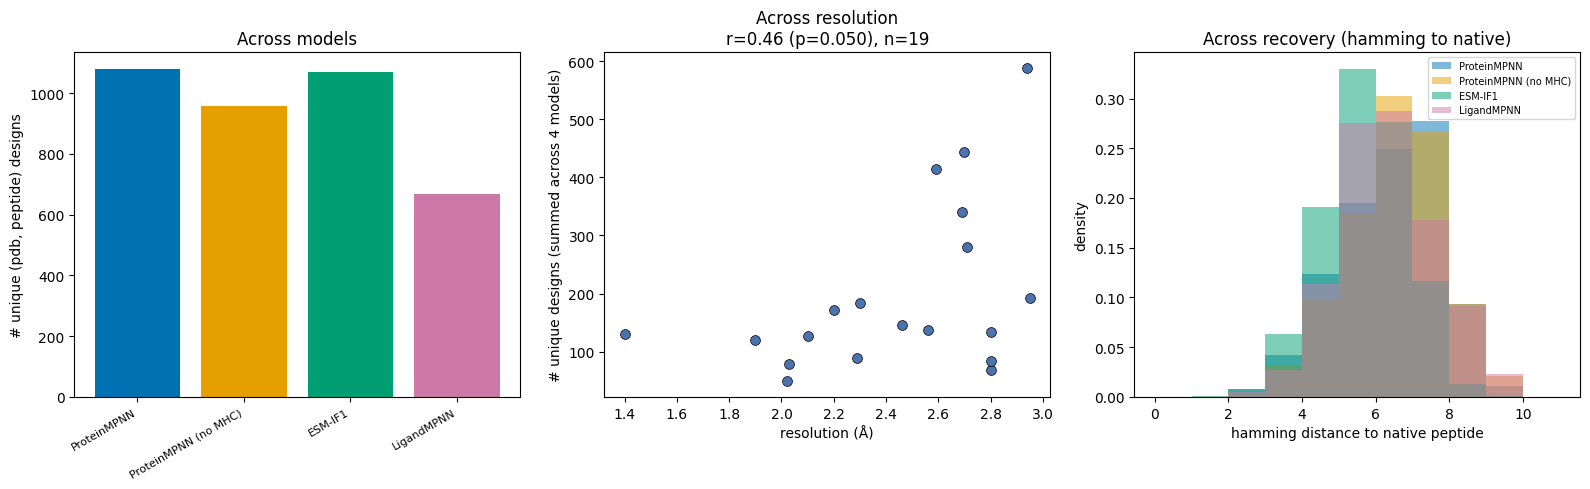

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_design_distributions.png


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

counts = df.groupby("model").size().reindex(MODELS)
axes[0].bar(range(len(MODELS)), counts.values, color=[MODEL_COLOR[m] for m in MODELS])
axes[0].set_xticks(range(len(MODELS)))
axes[0].set_xticklabels([MODEL_LABEL[m] for m in MODELS], rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("# unique (pdb, peptide) designs")
axes[0].set_title("Across models")

res_counts = df.groupby(["pdb", "resolution_A"]).size().reset_index(name="n_unique")
axes[1].scatter(res_counts["resolution_A"], res_counts["n_unique"], color="#4C72B0", s=50,
               edgecolor="black", linewidth=0.5)
r, p = pearsonr(res_counts["resolution_A"], res_counts["n_unique"])
axes[1].set_xlabel("resolution (Å)")
axes[1].set_ylabel("# unique designs (summed across 4 models)")
axes[1].set_title(f"Across resolution\nr={r:.2f} (p={p:.3f}), n={len(res_counts)}")

for model in MODELS:
    sub = df[df.model == model]
    axes[2].hist(sub["hamming_to_native"], bins=range(0, 12), alpha=0.5, density=True,
                color=MODEL_COLOR[model], label=MODEL_LABEL[model])
axes[2].set_xlabel("hamming distance to native peptide")
axes[2].set_ylabel("density")
axes[2].set_title("Across recovery (hamming to native)")
axes[2].legend(fontsize=7)

fig.tight_layout()
out = FIG_DIR / "fig_panel6_design_distributions.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 2. The scored table

In [3]:
df[["pdb", "model", "peptide", "native", "score", "resolution_A", "hamming_to_native",
   "n_anchors_recovered", "mhcflurry_ic50_nM", "esmcba_prediction"]].head(10)

,pdb,model,peptide,native,score,resolution_A,hamming_to_native,n_anchors_recovered,mhcflurry_ic50_nM,esmcba_prediction
0,2P5W,vanilla,MLPQYDTPF,SLLMWITQC,0.9547,2.2,7,1,1429.902708,4.331568
1,2P5W,vanilla,MLPNYFTPF,SLLMWITQC,0.9283,2.2,7,1,390.770529,4.197661
2,2P5W,vanilla,MLPNYFTRF,SLLMWITQC,0.9868,2.2,7,1,962.015451,4.144500
3,2P5W,vanilla,MLPNYDTPF,SLLMWITQC,0.9947,2.2,7,1,1342.397035,4.222630
4,2P5W,vanilla,MLPNWFTPF,SLLMWITQC,0.9704,2.2,6,1,263.995545,4.247863
5,2P5W,vanilla,MLPQYDTPL,SLLMWITQC,1.0075,2.2,7,1,27.972350,2.148924
6,2P5W,vanilla,MLPQYDTRF,SLLMWITQC,0.9835,2.2,7,1,2972.662515,4.254077
7,2P5W,vanilla,MLPQYFTKF,SLLMWITQC,1.0885,2.2,7,1,651.289670,4.301714
8,2P5W,vanilla,MLPNYLTRF,SLLMWITQC,1.0785,2.2,7,1,898.876930,4.224565
9,2P5W,vanilla,MLPNWFTRF,SLLMWITQC,1.0397,2.2,6,1,544.643516,4.185442


## 3. UMAP, 2x3 panel

One shared UMAP layout (fit jointly over all unique peptides' ESMCBA embeddings), recolored six ways.
Where a color variable doesn't apply to a point (ESM-IF1 has no usable per-design score), that point is
grayed out -- solid gray, not a transparent/faded version of the color scale, so "not applicable" is
never confused with "low value".

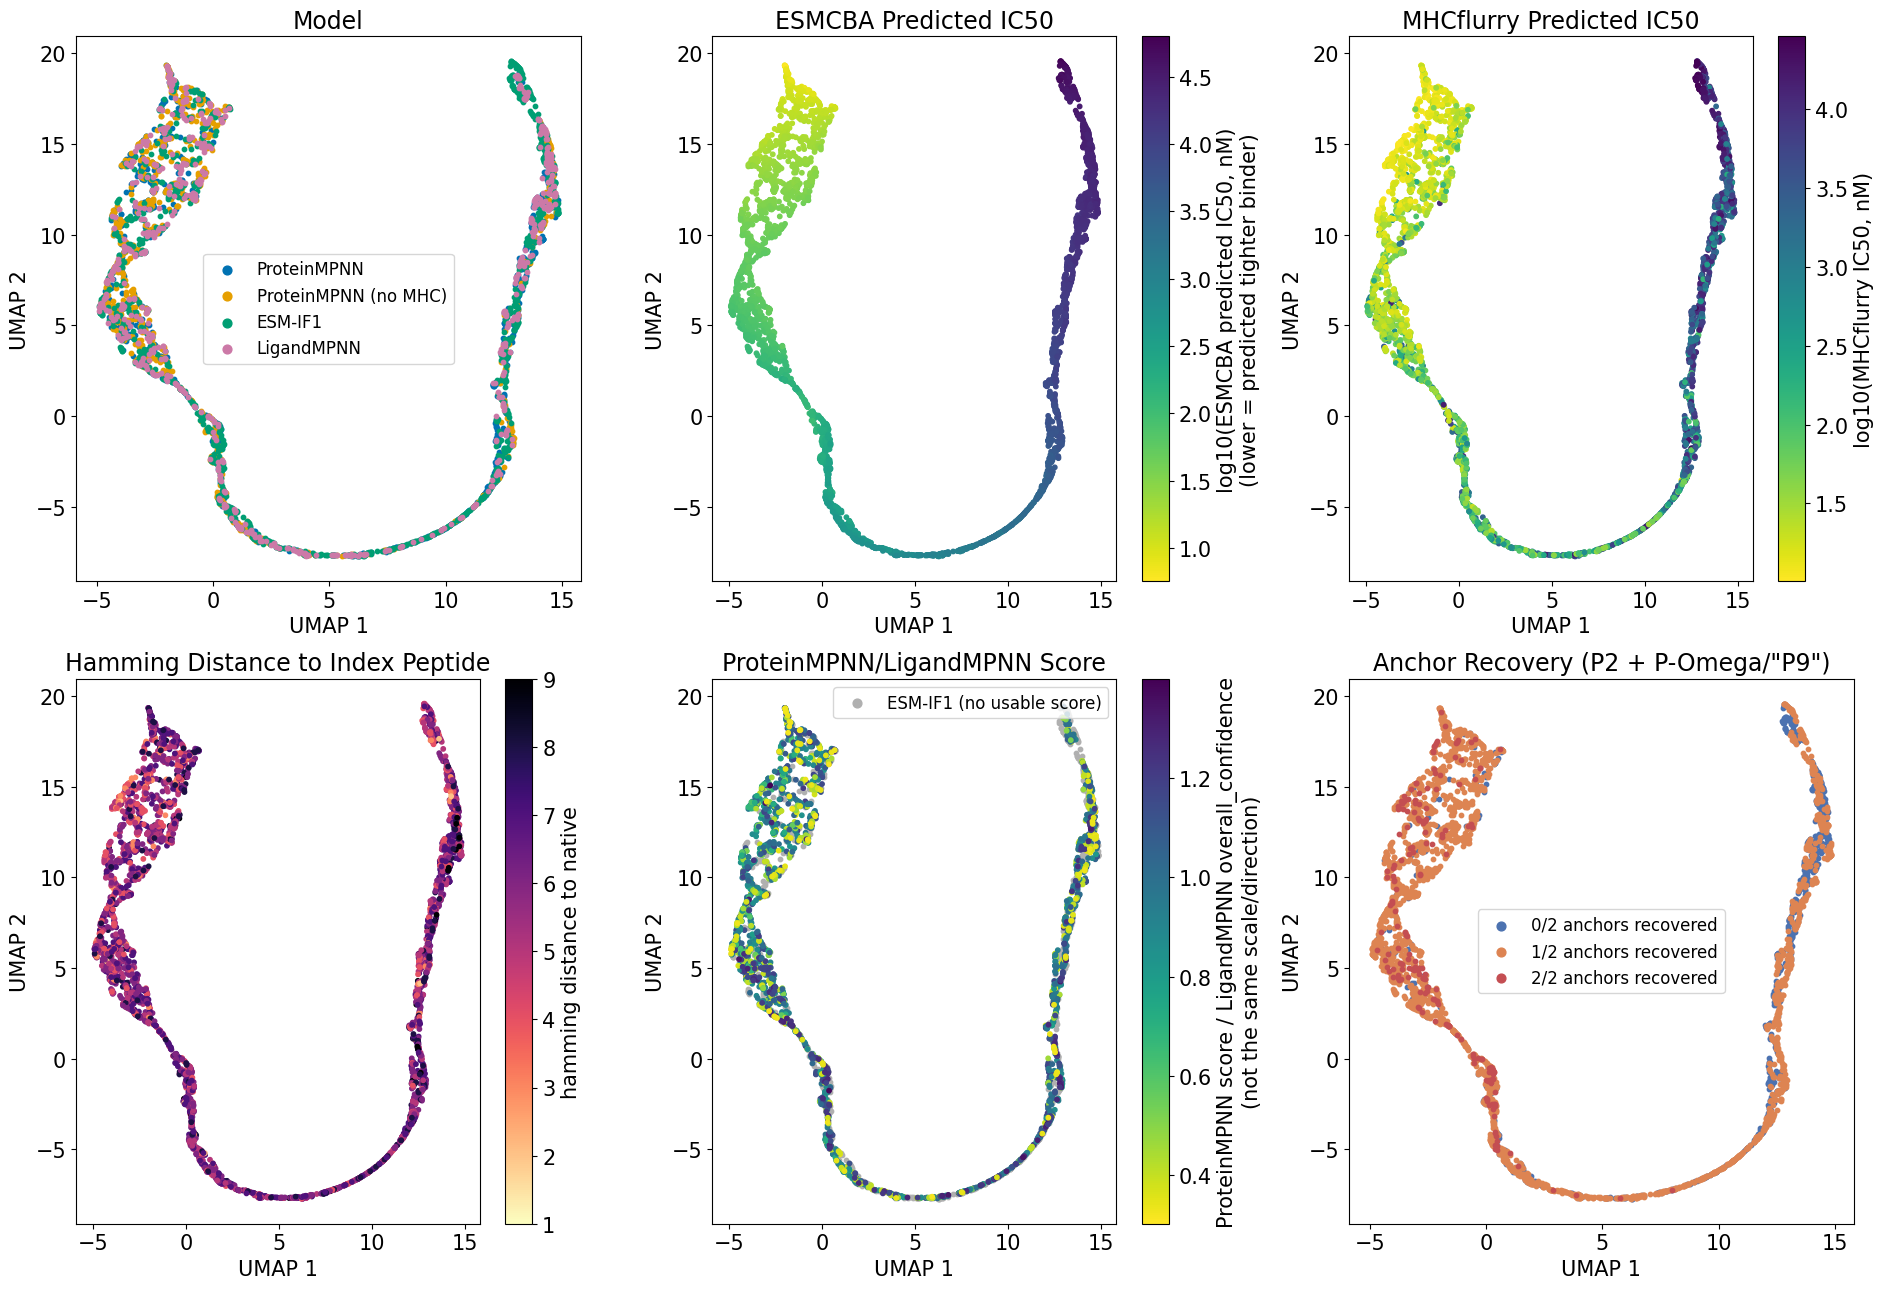

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_umap_2x3.png


In [4]:
TITLE_FS, LABEL_FS, TICK_FS, LEGEND_FS, CBAR_FS = 17, 15, 15, 12, 15
fig, axes = plt.subplots(2, 3, figsize=(19, 13))

# (1) Model
ax = axes[0, 0]
for model in MODELS:
    sub = df[df.model == model]
    ax.scatter(sub["UMAP_1"], sub["UMAP_2"], s=10, color=MODEL_COLOR[model], label=MODEL_LABEL[model])
ax.set_title("Model", fontsize=TITLE_FS)
ax.legend(fontsize=LEGEND_FS, markerscale=2)

# (2) ESMCBA predicted score
ax = axes[0, 1]
sc = ax.scatter(df["UMAP_1"], df["UMAP_2"], s=10, c=df["esmcba_prediction"], cmap="viridis_r")
cb = fig.colorbar(sc, ax=ax, label="log10(ESMCBA predicted IC50, nM)\n(lower = predicted tighter binder)")
cb.ax.tick_params(labelsize=TICK_FS); cb.set_label(cb.ax.get_ylabel(), fontsize=LABEL_FS)
ax.set_title("ESMCBA Predicted IC50", fontsize=TITLE_FS)

# (3) MHCFlurry predicted IC50 (log scale)
ax = axes[0, 2]
sc = ax.scatter(df["UMAP_1"], df["UMAP_2"], s=10, c=np.log10(df["mhcflurry_ic50_nM"]), cmap="viridis_r")
cb = fig.colorbar(sc, ax=ax, label="log10(MHCflurry IC50, nM)")
cb.ax.tick_params(labelsize=TICK_FS); cb.set_label(cb.ax.get_ylabel(), fontsize=LABEL_FS)
ax.set_title("MHCflurry Predicted IC50", fontsize=TITLE_FS)

# (4) Hamming distance to native
ax = axes[1, 0]
sc = ax.scatter(df["UMAP_1"], df["UMAP_2"], s=10, c=df["hamming_to_native"], cmap="magma_r")
cb = fig.colorbar(sc, ax=ax, label="hamming distance to native")
cb.ax.tick_params(labelsize=TICK_FS); cb.set_label(cb.ax.get_ylabel(), fontsize=LABEL_FS)
ax.set_title("Hamming Distance to Index Peptide", fontsize=TITLE_FS)

# (5) ProteinMPNN/LigandMPNN score; ESM-IF1 (no usable score) grayed out
ax = axes[1, 1]
has_score = df["score"].notna()
ax.scatter(df.loc[~has_score, "UMAP_1"], df.loc[~has_score, "UMAP_2"], s=10, color=GRAY,
          label="ESM-IF1 (no usable score)")
sc = ax.scatter(df.loc[has_score, "UMAP_1"], df.loc[has_score, "UMAP_2"], s=10,
               c=df.loc[has_score, "score"], cmap="viridis_r")
cb = fig.colorbar(sc, ax=ax, label="ProteinMPNN score / LigandMPNN overall_confidence\n(not the same scale/direction)")
cb.ax.tick_params(labelsize=TICK_FS); cb.set_label(cb.ax.get_ylabel(), fontsize=LABEL_FS)
ax.set_title("ProteinMPNN/LigandMPNN Score", fontsize=TITLE_FS)
ax.legend(fontsize=LEGEND_FS, markerscale=2, loc="upper right")

# (6) # anchors recovered (P2 + P-Omega/"P9")
ax = axes[1, 2]
anchor_colors = {0: "#4C72B0", 1: "#DD8452", 2: "#C44E52"}
for n_anchor, color in anchor_colors.items():
    sub = df[df.n_anchors_recovered == n_anchor]
    ax.scatter(sub["UMAP_1"], sub["UMAP_2"], s=10, color=color, label=f"{n_anchor}/2 anchors recovered")
ax.set_title("Anchor Recovery (P2 + P-Omega/\"P9\")", fontsize=TITLE_FS)
ax.legend(fontsize=LEGEND_FS, markerscale=2)

for ax in axes.flat:
    ax.set_xlabel("UMAP 1", fontsize=LABEL_FS)
    ax.set_ylabel("UMAP 2", fontsize=LABEL_FS)
    ax.tick_params(axis="both", labelsize=TICK_FS)

fig.tight_layout()
out = FIG_DIR / "fig_panel6_umap_2x3.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 4. Does ESMCBA agree with MHCflurry at all?

Two independent predictors (different architectures, different training procedures) scoring the same
peptides for the same allele. Both report log10(predicted IC50, nM), so the standard 500 nM strong-binder
cutoff (log10(500) = 2.70) applies identically to both axes. If they agree, that's real signal about
binding, not an artifact of either model individually -- if they don't, at least one of them isn't
telling us much about this particular peptide set. Broken out per model (2x2) rather than pooled, so the
agreement isn't hiding a case where it only holds for one model's designs -- colored by local point
density (Gaussian KDE), with everything outside the joint 500 nM quadrant (strong by *both* MHCflurry
and ESMCBA) rendered more transparent, so the double-strong-binder population isn't visually swamped by
the much larger pileup that is weak by at least one predictor.

ProteinMPNN: Pearson r=0.867 (p=0.00e+00), Spearman rho=0.880 (p=0.00e+00), n=1081
ProteinMPNN (no MHC): Pearson r=0.866 (p=3.66e-290), Spearman rho=0.872 (p=1.73e-298), n=958
ESM-IF1: Pearson r=0.831 (p=5.80e-274), Spearman rho=0.838 (p=1.99e-283), n=1069
LigandMPNN: Pearson r=0.911 (p=1.15e-258), Spearman rho=0.869 (p=2.75e-205), n=668


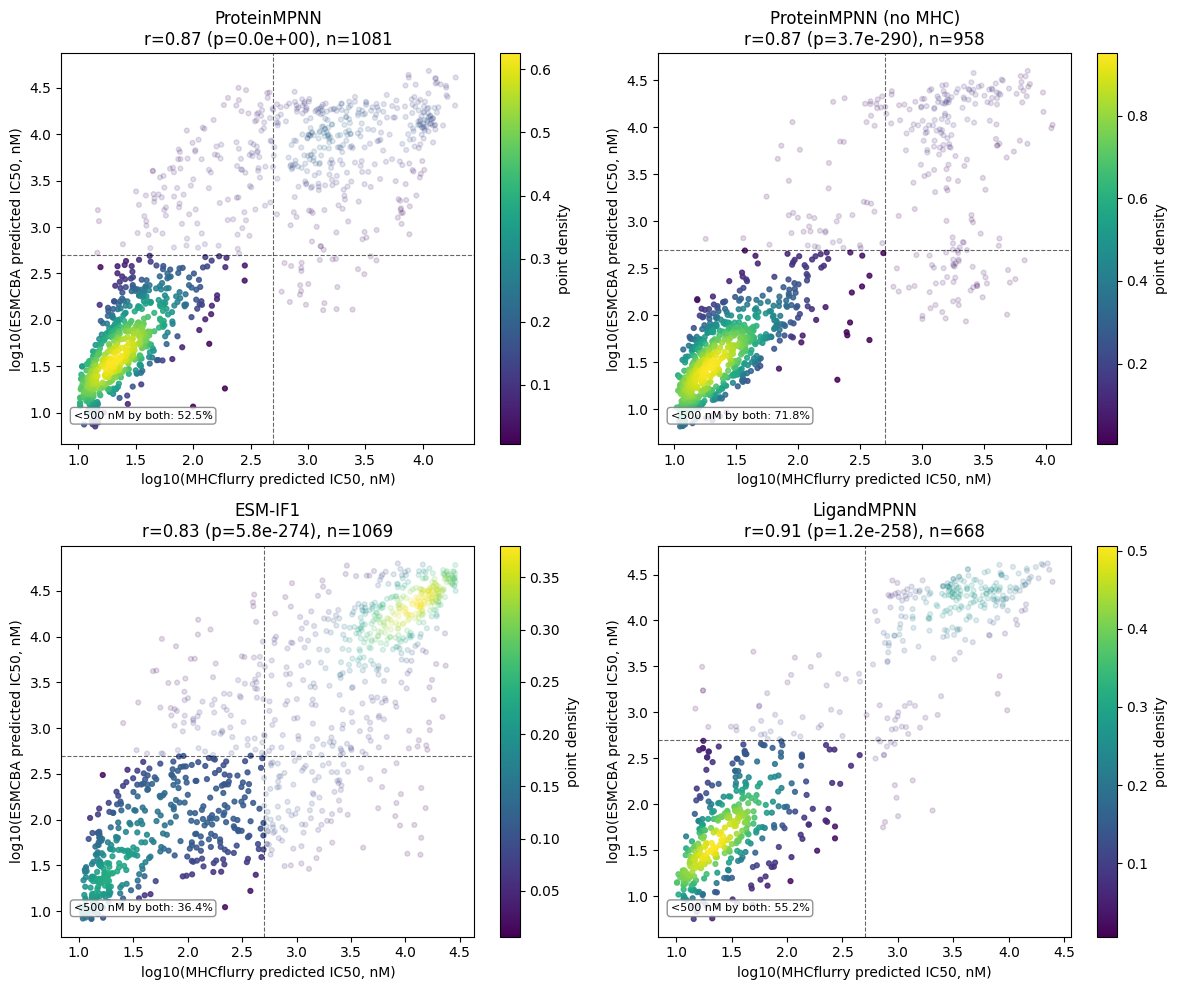

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_esmcba_vs_mhcflurry_by_model.png


In [5]:
LOG500 = np.log10(500)
cmap_density = plt.get_cmap("viridis")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, model in zip(axes.flat, MODELS):
    sub = df[df.model == model]
    r, p = pearsonr(sub["esmcba_prediction"], np.log10(sub["mhcflurry_ic50_nM"]))
    rho, p_rho = spearmanr(sub["esmcba_prediction"], sub["mhcflurry_ic50_nM"])
    print(f"{MODEL_LABEL[model]}: Pearson r={r:.3f} (p={p:.2e}), Spearman rho={rho:.3f} "
         f"(p={p_rho:.2e}), n={len(sub)}")
    x = np.log10(sub["mhcflurry_ic50_nM"].values)
    y = sub["esmcba_prediction"].values
    density = gaussian_kde(np.vstack([x, y]))(np.vstack([x, y]))
    order = np.argsort(density)  # lowest density first, so denser points draw on top
    x, y, density = x[order], y[order], density[order]
    is_double_strong = (x < LOG500) & (y < LOG500)
    norm = plt.Normalize(density.min(), density.max())
    colors = cmap_density(norm(density))
    colors[~is_double_strong, 3] = 0.15
    colors[is_double_strong, 3] = 0.85
    sc = ax.scatter(x, y, c=colors, s=12)
    sm = plt.cm.ScalarMappable(cmap=cmap_density, norm=norm)
    fig.colorbar(sm, ax=ax, label="point density")
    ax.axvline(LOG500, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.axhline(LOG500, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    pct_double_strong = 100 * np.mean(is_double_strong)
    ax.text(0.03, 0.06, f"<500 nM by both: {pct_double_strong:.1f}%",
           transform=ax.transAxes, fontsize=8, va="bottom", ha="left",
           bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="gray"))
    ax.set_xlabel("log10(MHCflurry predicted IC50, nM)")
    ax.set_ylabel("log10(ESMCBA predicted IC50, nM)")
    ax.set_title(f"{MODEL_LABEL[model]}\nr={r:.2f} (p={p:.1e}), n={len(sub)}")
fig.tight_layout()
out = FIG_DIR / "fig_panel6_esmcba_vs_mhcflurry_by_model.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 5. Same, pMHC-only context (no TCR)

Everything above was pMHC+TCR (full) context designs. This repeats the ESMCBA-vs-MHCflurry agreement
check for the pMHC-only design condition -- same 19 structures, same 4 models, same allele, but the
designs themselves come from a much larger and more diverse unique-peptide set (9,190 vs. 3,557), since
removing the TCR from the design context is already established elsewhere in this project to increase
design diversity.

10009 (pdb, model, peptide) rows, 9190 distinct peptides, 19 structures
ProteinMPNN: Pearson r=0.938 (p=0.00e+00), Spearman rho=0.909 (p=0.00e+00), n=3671


ProteinMPNN (no MHC): Pearson r=0.887 (p=0.00e+00), Spearman rho=0.812 (p=0.00e+00), n=2362


ESM-IF1: Pearson r=0.831 (p=0.00e+00), Spearman rho=0.833 (p=0.00e+00), n=1865
LigandMPNN: Pearson r=0.939 (p=0.00e+00), Spearman rho=0.885 (p=0.00e+00), n=2111


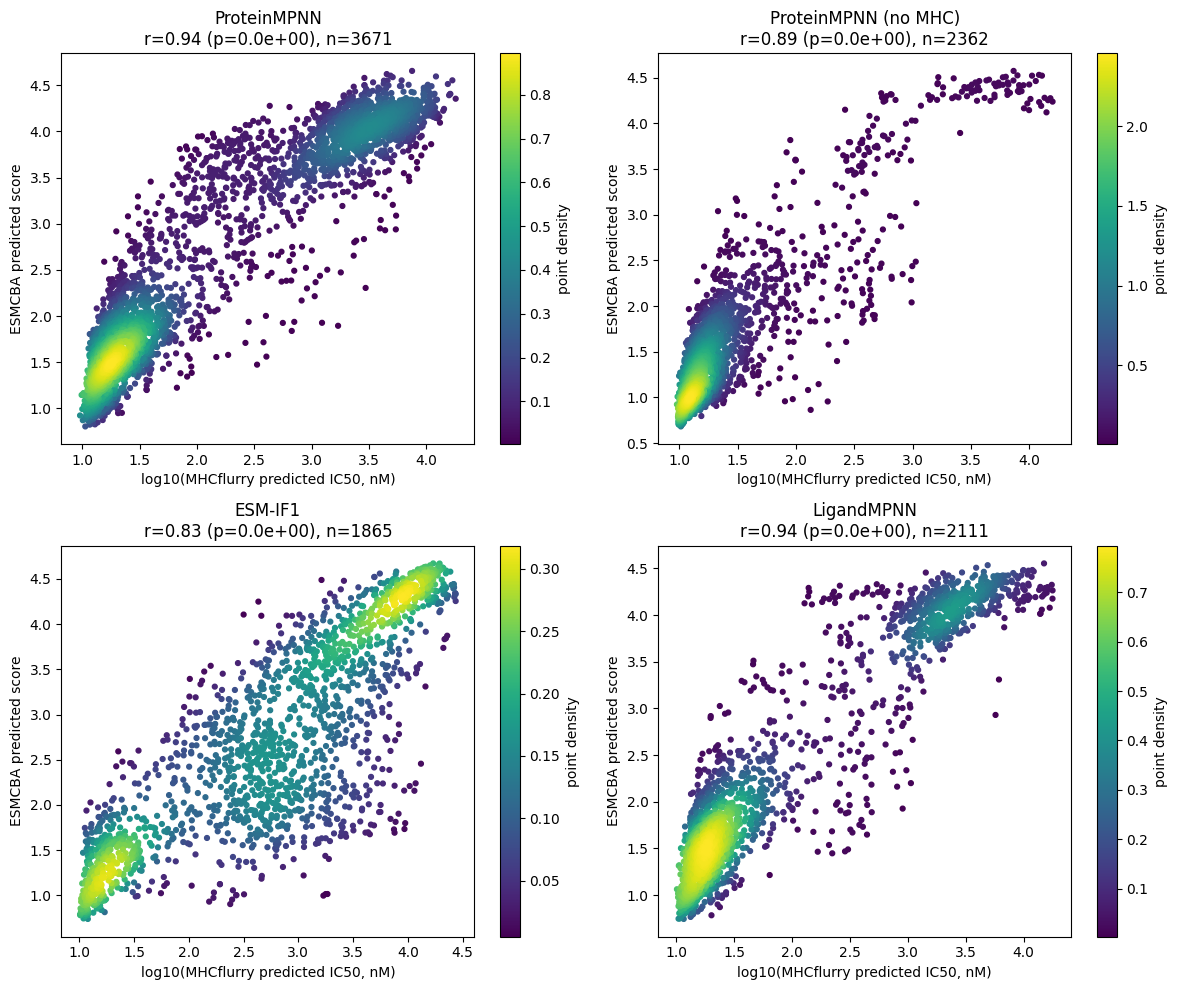

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_esmcba_vs_mhcflurry_by_model_mhconly.png


In [6]:
meta_mhconly = pd.read_csv(ROOT / "outputs/analysis/panel_unique_peptides_metadata_mhconly.csv")
mhcflurry_mhconly = pd.read_csv(ROOT / "outputs/analysis/panel_unique_peptides_mhcflurry_mhconly.csv")
esmcba_mhconly = pd.read_csv(ROOT / "outputs/analysis/panel_unique_peptides_esmcba_mhconly.csv")
df_mhconly = meta_mhconly.merge(mhcflurry_mhconly, on="peptide", how="left").merge(
    esmcba_mhconly, on="peptide", how="left")
print(f"{len(df_mhconly)} (pdb, model, peptide) rows, {df_mhconly['peptide'].nunique()} distinct "
     f"peptides, {df_mhconly['pdb'].nunique()} structures")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, model in zip(axes.flat, MODELS):
    sub = df_mhconly[df_mhconly.model == model]
    r, p = pearsonr(sub["esmcba_prediction"], np.log10(sub["mhcflurry_ic50_nM"]))
    rho, p_rho = spearmanr(sub["esmcba_prediction"], sub["mhcflurry_ic50_nM"])
    print(f"{MODEL_LABEL[model]}: Pearson r={r:.3f} (p={p:.2e}), Spearman rho={rho:.3f} "
         f"(p={p_rho:.2e}), n={len(sub)}")
    x = np.log10(sub["mhcflurry_ic50_nM"].values)
    y = sub["esmcba_prediction"].values
    density = gaussian_kde(np.vstack([x, y]))(np.vstack([x, y]))
    order = np.argsort(density)
    sc = ax.scatter(x[order], y[order], c=density[order], s=12, cmap="viridis")
    fig.colorbar(sc, ax=ax, label="point density")
    ax.set_xlabel("log10(MHCflurry predicted IC50, nM)")
    ax.set_ylabel("ESMCBA predicted score")
    ax.set_title(f"{MODEL_LABEL[model]}\nr={r:.2f} (p={p:.1e}), n={len(sub)}")
fig.tight_layout()
out = FIG_DIR / "fig_panel6_esmcba_vs_mhcflurry_by_model_mhconly.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 6. Which model produces more strong binders (MHCflurry IC50 < 500 nM)?

500 nM is the standard IEDB/NetMHC "binder" threshold (not a special cutoff picked for this analysis).
Full pMHC+TCR context. Omnibus test: 4x2 contingency table (model x strong/weak), chi-square test of
independence -- does strong-binder rate depend on which model made the design at all? Follow-up:
pairwise Fisher's exact tests between every pair of models, Bonferroni-corrected across all 6 pairs
(consistent with how every other multi-way comparison in this project's notebooks has been corrected).

            n_strong  n_total  pct_strong
model                                    
vanilla          705     1081   65.217391
noMHC            742      958   77.453027
ESM-IF1          477     1069   44.621141
LigandMPNN       408      668   61.077844

omnibus chi-square (model x strong/weak binder): chi2=238.46, dof=3, p=2.05e-51

pairwise Fisher's exact (Bonferroni x6):
  ProteinMPNN            vs ProteinMPNN (no MHC)  : 65.2% vs 77.5%, odds_ratio=1.83, p_raw=1.23e-09, p_bonferroni=7.38e-09 (*)
  ProteinMPNN            vs ESM-IF1               : 65.2% vs 44.6%, odds_ratio=0.43, p_raw=7.09e-22, p_bonferroni=4.25e-21 (*)
  ProteinMPNN            vs LigandMPNN            : 65.2% vs 61.1%, odds_ratio=0.84, p_raw=8.22e-02, p_bonferroni=4.93e-01 (ns)
  ProteinMPNN (no MHC)   vs ESM-IF1               : 77.5% vs 44.6%, odds_ratio=0.23, p_raw=1.45e-52, p_bonferroni=8.70e-52 (*)
  ProteinMPNN (no MHC)   vs LigandMPNN            : 77.5% vs 61.1%, odds_ratio=0.46, p_raw=1.56e-12, p_bonferroni=9.

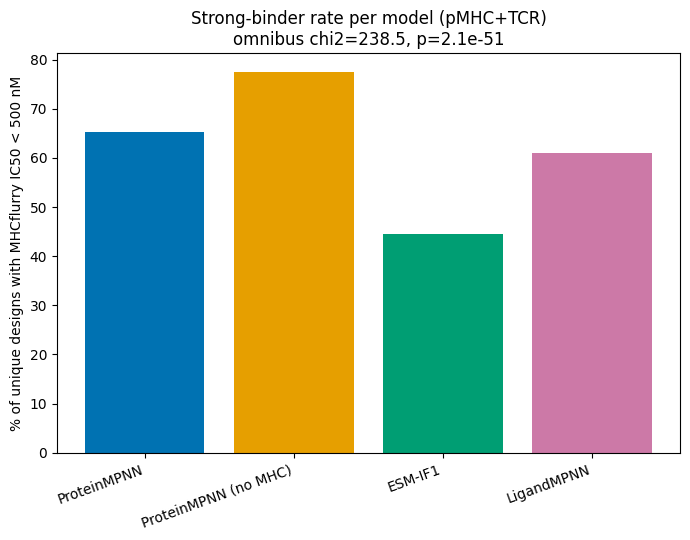

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_strong_binder_rate_by_model.png


In [7]:
df["strong_binder"] = df["mhcflurry_ic50_nM"] < 500

rate_table = df.groupby("model")["strong_binder"].agg(["sum", "count"])
rate_table["pct_strong"] = 100 * rate_table["sum"] / rate_table["count"]
rate_table = rate_table.reindex(MODELS)
print(rate_table.rename(columns={"sum": "n_strong", "count": "n_total"}))

contingency = pd.crosstab(df["model"], df["strong_binder"]).reindex(MODELS)
chi2, p_omnibus, dof, expected = chi2_contingency(contingency)
print(f"\nomnibus chi-square (model x strong/weak binder): chi2={chi2:.2f}, dof={dof}, p={p_omnibus:.2e}")

print("\npairwise Fisher's exact (Bonferroni x6):")
pairs = [(a, b) for i, a in enumerate(MODELS) for b in MODELS[i + 1:]]
for a, b in pairs:
    table = contingency.loc[[a, b]].values
    odds, p_raw = fisher_exact(table)
    p_adj = min(1.0, p_raw * len(pairs))
    sig = "*" if p_adj < 0.05 else "ns"
    print(f"  {MODEL_LABEL[a]:22s} vs {MODEL_LABEL[b]:22s}: "
         f"{rate_table.loc[a, 'pct_strong']:.1f}% vs {rate_table.loc[b, 'pct_strong']:.1f}%, "
         f"odds_ratio={odds:.2f}, p_raw={p_raw:.2e}, p_bonferroni={p_adj:.2e} ({sig})")

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.bar(range(len(MODELS)), rate_table["pct_strong"], color=[MODEL_COLOR[m] for m in MODELS])
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels([MODEL_LABEL[m] for m in MODELS], rotation=20, ha="right")
ax.set_ylabel("% of unique designs with MHCflurry IC50 < 500 nM")
ax.set_title(f"Strong-binder rate per model (pMHC+TCR)\n"
            f"omnibus chi2={chi2:.1f}, p={p_omnibus:.1e}")
fig.tight_layout()
out = FIG_DIR / "fig_panel6_strong_binder_rate_by_model.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 7. Does removing the TCR (mhconly) shift the predicted-affinity distribution?

Per model, full (pMHC+TCR) vs. mhconly (no TCR) -- same unique-peptide-level MHCflurry/ESMCBA scores
already computed above, now compared as two distributions rather than one pooled scatter. Unpaired
(the two conditions produce different peptide sets, not matched pairs), Mann-Whitney U per model for
both predictors.

ProteinMPNN, log10(MHCflurry IC50, nM): full mean=2.20 (n=1081), mhconly mean=2.12 (n=3671), Mann-Whitney p=1.74e-05
ProteinMPNN, ESMCBA predicted score: full mean=2.69 (n=1081), mhconly mean=2.56 (n=3671), Mann-Whitney p=4.10e-05


ProteinMPNN (no MHC), log10(MHCflurry IC50, nM): full mean=1.88 (n=958), mhconly mean=1.38 (n=2362), Mann-Whitney p=2.15e-95
ProteinMPNN (no MHC), ESMCBA predicted score: full mean=2.13 (n=958), mhconly mean=1.55 (n=2362), Mann-Whitney p=3.74e-76
ESM-IF1, log10(MHCflurry IC50, nM): full mean=2.84 (n=1069), mhconly mean=2.72 (n=1865), Mann-Whitney p=3.53e-04
ESM-IF1, ESMCBA predicted score: full mean=2.96 (n=1069), mhconly mean=2.68 (n=1865), Mann-Whitney p=2.11e-10
LigandMPNN, log10(MHCflurry IC50, nM): full mean=2.30 (n=668), mhconly mean=1.98 (n=2111), Mann-Whitney p=3.26e-19
LigandMPNN, ESMCBA predicted score: full mean=2.68 (n=668), mhconly mean=2.38 (n=2111), Mann-Whitney p=8.54e-13


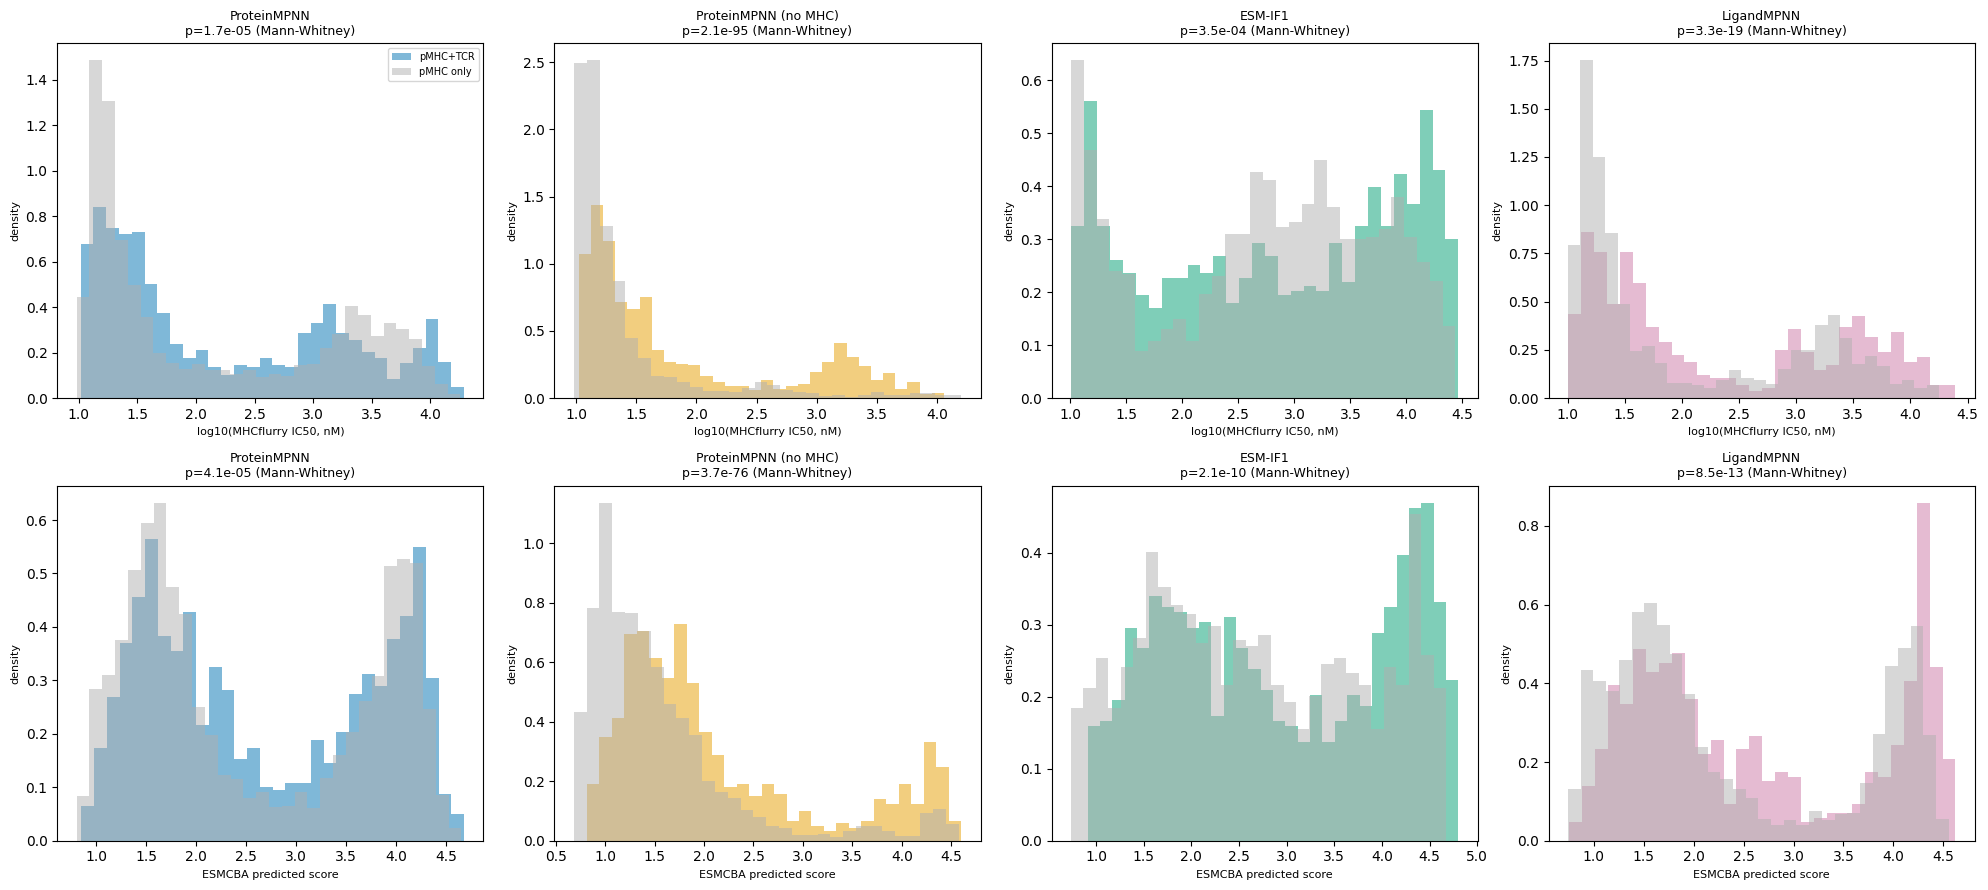

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_full_vs_mhconly_affinity_shift.png


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for col, model in enumerate(MODELS):
    full_sub = df[df.model == model]
    mhconly_sub = df_mhconly[df_mhconly.model == model]

    for row, (col_name, xlabel, transform) in enumerate([
        ("mhcflurry_ic50_nM", "log10(MHCflurry IC50, nM)", np.log10),
        ("esmcba_prediction", "ESMCBA predicted score", lambda v: v),
    ]):
        ax = axes[row, col]
        full_vals = transform(full_sub[col_name].dropna().values)
        mhconly_vals = transform(mhconly_sub[col_name].dropna().values)
        stat, p = mannwhitneyu(full_vals, mhconly_vals, alternative="two-sided")
        ax.hist(full_vals, bins=30, alpha=0.5, density=True, color=MODEL_COLOR[model], label="pMHC+TCR")
        ax.hist(mhconly_vals, bins=30, alpha=0.5, density=True, color=GRAY, label="pMHC only")
        ax.set_xlabel(xlabel, fontsize=8)
        ax.set_ylabel("density", fontsize=8)
        ax.set_title(f"{MODEL_LABEL[model]}\np={p:.1e} (Mann-Whitney)", fontsize=9)
        if row == 0 and col == 0:
            ax.legend(fontsize=7)
        print(f"{MODEL_LABEL[model]}, {xlabel}: full mean={full_vals.mean():.2f} "
             f"(n={len(full_vals)}), mhconly mean={mhconly_vals.mean():.2f} (n={len(mhconly_vals)}), "
             f"Mann-Whitney p={p:.2e}")
fig.tight_layout()
out = FIG_DIR / "fig_panel6_full_vs_mhconly_affinity_shift.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 8. Does removing the TCR shift the models' *own* design scores?

Sections 6-7 use two external predictors that never saw these designs during training. Here we ask a
different question: does each model's *own* score for its own designs (ProteinMPNN/ProteinMPNN-no-MHC
average per-residue negative log-likelihood -- lower is more confident; LigandMPNN overall_confidence --
higher is more confident) shift when the TCR is removed? ESM-IF1 has no usable per-design score and is
excluded. Pooled across all 19 structures (unpaired, Mann-Whitney U per model), then broken out per
structure (Bonferroni-corrected across the 19 structures) to see whether a pooled shift is uniform or
concentrated in a subset of structures.

Pooled across all structures:
  ProteinMPNN: full mean=1.016 (n=1081), mhconly mean=1.295 (n=3671), Mann-Whitney p=0.00e+00
  ProteinMPNN (no MHC): full mean=0.925 (n=958), mhconly mean=1.128 (n=2362), Mann-Whitney p=9.30e-201
  LigandMPNN: full mean=0.413 (n=668), mhconly mean=0.321 (n=2111), Mann-Whitney p=3.66e-222


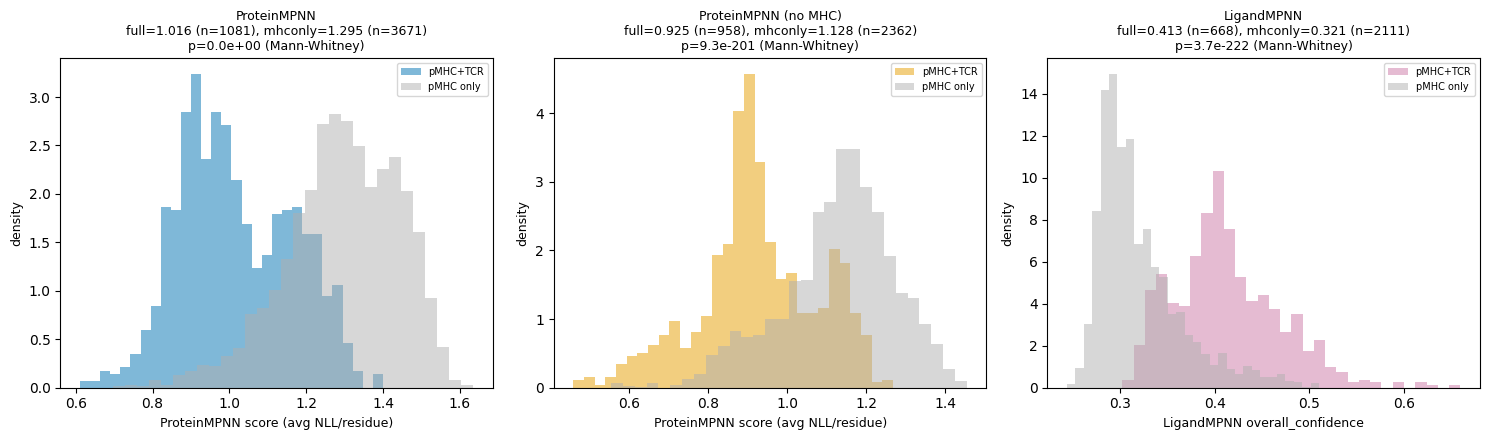

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_own_score_shift_pooled.png


In [9]:
score_full = meta[["pdb", "model", "score"]].dropna()
score_mhconly = meta_mhconly[["pdb", "model", "score"]].dropna()
SCORE_MODELS = ["vanilla", "noMHC", "LigandMPNN"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
print("Pooled across all structures:")
for ax, model in zip(axes, SCORE_MODELS):
    fv = score_full.loc[score_full.model == model, "score"].values
    mv = score_mhconly.loc[score_mhconly.model == model, "score"].values
    stat, p = mannwhitneyu(fv, mv, alternative="two-sided")
    ax.hist(fv, bins=30, alpha=0.5, density=True, color=MODEL_COLOR[model], label="pMHC+TCR")
    ax.hist(mv, bins=30, alpha=0.5, density=True, color=GRAY, label="pMHC only")
    xlabel = "LigandMPNN overall_confidence" if model == "LigandMPNN" else "ProteinMPNN score (avg NLL/residue)"
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("density", fontsize=9)
    ax.set_title(f"{MODEL_LABEL[model]}\nfull={fv.mean():.3f} (n={len(fv)}), mhconly={mv.mean():.3f} "
                f"(n={len(mv)})\np={p:.1e} (Mann-Whitney)", fontsize=9)
    ax.legend(fontsize=7)
    print(f"  {MODEL_LABEL[model]}: full mean={fv.mean():.3f} (n={len(fv)}), "
         f"mhconly mean={mv.mean():.3f} (n={len(mv)}), Mann-Whitney p={p:.2e}")
fig.tight_layout()
out = FIG_DIR / "fig_panel6_own_score_shift_pooled.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

Per-structure (Bonferroni n=19):
  ProteinMPNN: 17 significant, 2 not significant, 0 skipped (n<5) out of 19 structures
  ProteinMPNN (no MHC): 16 significant, 3 not significant, 0 skipped (n<5) out of 19 structures
  LigandMPNN: 15 significant, 3 not significant, 1 skipped (n<5) out of 19 structures


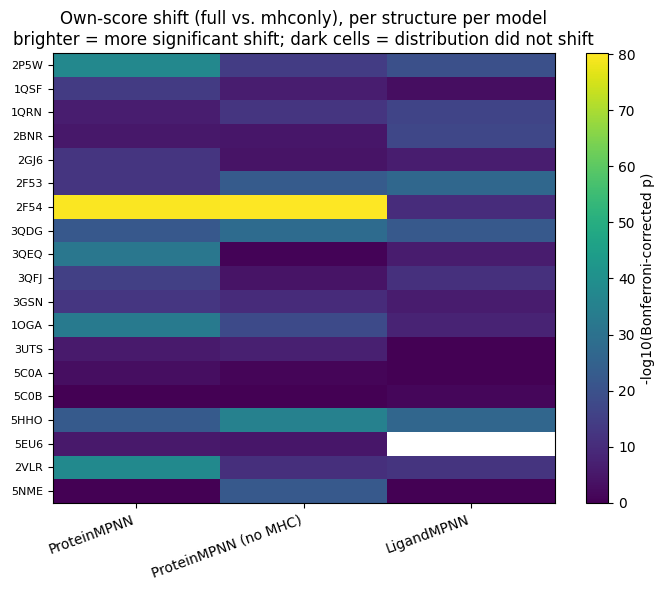

wrote /home/ubuntu/if-mhc/figures/fig_panel6_mhcflurry_esmcba_umap/fig_panel6_own_score_shift_by_structure.png


In [10]:
STRUCTS_SCORE = [p for p in meta["pdb"].unique() if p != "4MJI"]
n_structs = len(STRUCTS_SCORE)
sig_matrix = pd.DataFrame(index=STRUCTS_SCORE, columns=SCORE_MODELS, dtype=float)
print(f"Per-structure (Bonferroni n={n_structs}):")
for model in SCORE_MODELS:
    n_sig, n_ns, n_skip = 0, 0, 0
    for pdb in STRUCTS_SCORE:
        fv = score_full.loc[(score_full.model == model) & (score_full.pdb == pdb), "score"].values
        mv = score_mhconly.loc[(score_mhconly.model == model) & (score_mhconly.pdb == pdb), "score"].values
        if len(fv) < 5 or len(mv) < 5:
            sig_matrix.loc[pdb, model] = np.nan
            n_skip += 1
            continue
        stat, p = mannwhitneyu(fv, mv, alternative="two-sided")
        p_adj = min(1.0, p * n_structs)
        sig_matrix.loc[pdb, model] = p_adj
        if p_adj < 0.05:
            n_sig += 1
        else:
            n_ns += 1
    print(f"  {MODEL_LABEL[model]}: {n_sig} significant, {n_ns} not significant, "
         f"{n_skip} skipped (n<5) out of {n_structs} structures")

fig, ax = plt.subplots(figsize=(7, 6))
sig_display = -np.log10(sig_matrix.astype(float))
im = ax.imshow(sig_display.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(SCORE_MODELS)))
ax.set_xticklabels([MODEL_LABEL[m] for m in SCORE_MODELS], rotation=20, ha="right")
ax.set_yticks(range(n_structs))
ax.set_yticklabels(STRUCTS_SCORE, fontsize=8)
fig.colorbar(im, ax=ax, label="-log10(Bonferroni-corrected p)")
ax.set_title("Own-score shift (full vs. mhconly), per structure per model\nbrighter = more significant "
            "shift; dark cells = distribution did not shift")
fig.tight_layout()
out = FIG_DIR / "fig_panel6_own_score_shift_by_structure.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")